FFNN's Parameters

In [1]:
h_neurons = 6
l_rate = 0.00379
epoch_size = 30
b_size = 8

Extracting the learning set and test set from the .txt file that generated during eucildean distance

In [2]:

def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

Including the text files from the results directiory of euclidean distance. from 2003 to 2023, training and validation.
And 2024 to 2025 for Test.

In [3]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
import random
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_learning_data = np.array(extract_L_set(filePath))


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#separate the training_validation for Feature and Target
X = loaded_learning_data[:, :5] #first five col of the row is feature
y = loaded_learning_data[:, 5] # 6th value is the target

#split for train and val
X_train = X[30:]
X_val = X[:30]
y_train = y[30:]
y_val = y[:30]

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (115, 5)
Shape of y_train(115,)
Shape of X_val(30, 5)
Shape of y_val(30,)


The test data from **2024 to 2025**.

In [5]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]

X_test = scaler.transform(X_test)


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with non-linear function (sigmoid or relu), and a signle neuron output layer with linear function.
**The parameters are set at the top of this notebook**.

From seed 0 to 99, the ffnn trained, evaluate, and test. All the test prediction will do **median** at the last.

In [6]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import pandas as pd


def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    matches = tf.equal(true_sign, pred_sign)
    return tf.reduce_mean(tf.cast(matches, tf.float32)) * 100
# List to hold the predictions from all 100 runs
all_test_predictions = []
print(f"Start Training Model with Seed: 0 to 99")
# Loop through seeds 0 to 99
for current_seed in range(100):
    
    # Reset random seeds
    random.seed(current_seed)
    np.random.seed(current_seed)
    tf.random.set_seed(current_seed)
    
    # Build the model architecture 
    ffnn = Sequential()
    ffnn.add(Input(shape=(X_train.shape[1],)))
    ffnn.add(Dense(units=h_neurons, activation="sigmoid")) 
    ffnn.add(Dense(units=1, activation="linear"))
    
    # Setup callbacks with unique filepaths per seed so they don't overwrite
    best_model_path = f'models/best_model_seed_{current_seed}.keras'
    
    early_stopping = EarlyStopping(
        monitor='val_direction_accuracy', mode='max', patience=5, restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        filepath=best_model_path, monitor='val_direction_accuracy', 
        save_weights_only=False, mode='max', save_best_only=True, verbose=0
    )
    
    # Compile the model 
    ffnn.compile(
        optimizer=Adam(learning_rate=l_rate), 
        loss='mse', 
        metrics=[direction_accuracy]
    )
    
    # Fit the model 
    ffnn.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epoch_size, 
        batch_size=b_size,
        callbacks=[early_stopping, checkpoint],
        verbose=0 # Kept at 0 to avoid flooding console with 100 logs
    )
    
    # Load the best saved model for this specific seed
    best_model = tf.keras.models.load_model(
        best_model_path, custom_objects={'direction_accuracy': direction_accuracy}, compile=False
    )
    
    # Predict on the test set and flatten the array 
    y_pred = best_model.predict(X_test, verbose=0)
    all_test_predictions.append(np.ravel(y_pred))
    
    # Clear the Keras backend to prevent memory leaks during the loop
    tf.keras.backend.clear_session()
print(f"Completed Training Model with Seed: 0 to 99")

# --- Post-Processing: Median Calculation ---

# Convert the list to a NumPy matrix (Shape will be 100 rows x Number of Test Samples)
predictions_matrix = np.array(all_test_predictions)

# Calculate the median across the 0th axis (column-wise median per sample)
median_test_predictions = np.median(predictions_matrix, axis=0)

# Evaluate the ensemble (median) predictions against actual values [cite: 328, 329]
y_test_flat = np.ravel(y_test)
ffnn_direction_match = (np.sign(y_test_flat) == np.sign(median_test_predictions)).astype(int)

# Calculate and display the final ensemble accuracy
ffnn_test_acc = ffnn_direction_match.mean() * 100
print(f"\nFinal (Median) Test Prediction Accuracy: {ffnn_test_acc:.2f}%")

I0000 00:00:1779202005.684286  564766 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779202005.744842  564766 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779202007.449373  564766 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Start Training Model with Seed: 0 to 99


E0000 00:00:1779202008.384300  564766 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Completed Training Model with Seed: 0 to 99

Final (Median) Test Prediction Accuracy: 54.55%


--- Median Predictions vs Actual Values ---
      Actual  Median_Predicted  Direction_Match
0  -0.017473          0.056894                0
1  -0.339443          0.122209                0
2   0.031541          0.075316                1
3  -0.215161          0.080249                0
4  -0.087107          0.102881                0
5   0.485383          0.073954                1
6  -0.220254          0.066669                0
7   0.307394          0.062398                1
8   0.306878          0.083119                1
9   0.113420          0.123612                1
10  0.198257          0.127049                1


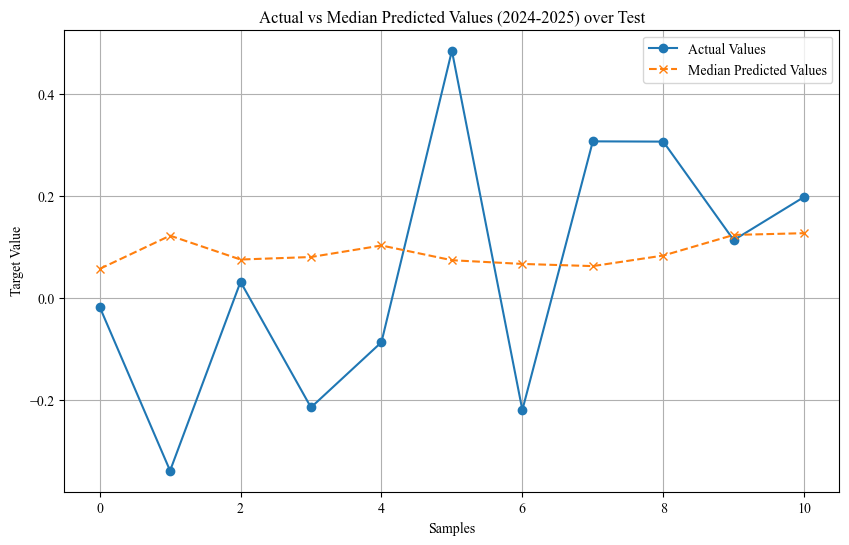

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame to view Actual vs Median Predicted values
median_results_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Median_Predicted': median_test_predictions,
    'Direction_Match': ffnn_direction_match
})

print("--- Median Predictions vs Actual Values ---")
print(median_results_df)

# Plot the Actual vs Median Predicted values
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))

plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(median_test_predictions)), median_test_predictions, label="Median Predicted Values", marker="x", linestyle="--")

plt.title("Actual vs Median Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.savefig("sigmoid_median_0to99.png", dpi=300, bbox_inches="tight")
plt.show()